In [213]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [214]:
LMPD_Analytics = pd.read_csv("../Data/LMPD_crimes.csv")
LMPD_Analytics

,incident_number,date_reported,date_occurred,badge_id,offense_classification,offense_code_name,nibrs_code,nibrs_group_name,was_offense_completed,lmpd_division,lmpd_beat,location_category,block_address,city,zip_code,ObjectId
0,LMPD25147130,12/10/2025 3:57:00 PM,2/20/2024 5:00:00 AM,8701.0,19 THEFT FR BLDG,"TBUT OR DISP FROM BUILDING $1,000 < $10,000 51...",23D,A,YES,8TH DIVISION,812,RESIDENCE/HOME,5000 BLOCK CLIFFWOOD RD,LOUISVILLE,40222,1
1,LMPD25144947,12/5/2025 5:28:00 PM,11/16/2024 5:00:00 AM,8701.0,29 FRAUD IMPERSONATION,THEFT OF IDENTITY OF ANOTHER WITHOUT CONSENT 5...,26C,A,YES,4TH DIVISION,424,RESIDENCE/HOME,500 BLOCK LONGFIELD AVE,LOUISVILLE,40215,2
2,LMPD25140113,11/24/2025 4:22:00 AM,7/9/2024 4:00:00 AM,8631.0,29 FRAUD IMPERSONATION,THEFT OF IDENTITY OF ANOTHER WITHOUT CONSENT 5...,26C,A,YES,8TH DIVISION,824,RESIDENCE/HOME,100 BLOCK LA FONTENAY DR,DOUGLASS HILLS,40223,3
3,LMPD25139843,11/23/2025 2:37:00 PM,11/15/2024 9:00:00 PM,8560.0,14 AUTO THEFT,"TBUT OR DISP AUTO $1,000 < $10,000 514.030 241...",240,A,YES,2ND DIVISION,223,HIGHWAY/ ROAD/ ALLEY/ STREET/ SIDEWALK,1300 BLOCK S 26TH ST,LOUISVILLE,40210,4
4,LMPD25020252,2/24/2025 8:52:00 PM,12/19/2024 3:51:00 AM,8646.0,18 SHOPLIFTING,TBUT OR DISP SHOPLIFTING 514.030 24230 23C,23C,A,YES,3RD DIVISION,315,GROCERY/ SUPERMARKET,9900 BLOCK DIXIE HWY,LOUISVILLE,40272,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70771,LMPD23110521,11/12/2023 1:00:00 PM,1/16/2024 5:00:00 AM,7444.0,46 FAMILY OFFENSES,VIOLATION OF KENTUCKY EPO/DVO 403.763 02763 90F,90F,B,NO,3RD DIVISION,331,RESIDENCE/HOME,2800 BLOCK DE MEL AVE,LOUISVILLE,40214,70772
70772,LMPD23110062,11/10/2023 9:32:00 PM,2/3/2024 9:54:00 PM,5434.0,33 STOLEN PROPERTY,"RECEIVING STOLEN PROPERTY $1,000 < $10,000 514...",280,A,YES,3RD DIVISION,331,RESIDENCE/HOME,5300 BLOCK MILNER RD,LOUISVILLE,40216,70773
70773,LMPD23109383,11/9/2023 1:11:00 PM,4/13/2024 9:53:00 AM,7755.0,33 STOLEN PROPERTY,RECEIVING STOLEN PROPERTY (FIREARM) 514.110 28...,280,A,YES,4TH DIVISION,412,OTHER RESIDENCE (APARTMENT/CONDO),700 BLOCK S HANCOCK ST,LOUISVILLE,40203,70774
70774,LMPD23109575,11/8/2023 11:00:00 PM,10/5/2024 1:47:00 AM,8515.0,56 ALL OTHER OFFENSES,RECOVERY OF STOLEN PROPERTY ***.*** 03016 90Z,90Z,B,NO,4TH DIVISION,423,RESIDENCE/HOME,3600 BLOCK KAHLERT AVE,LOUISVILLE,40215,70775


In [215]:
LMPD_Analytics['date_occurred'] = pd.to_datetime(LMPD_Analytics['date_occurred'])
LMPD_Analytics['date_reported'] = pd.to_datetime(LMPD_Analytics['date_reported'])


In [216]:
LMPD_Analytics['report_delay_days'] = (
    LMPD_Analytics['date_reported'] - LMPD_Analytics['date_occurred']
).dt.days #This code was provided by ChatGpt

LMPD_Timelines = (
    LMPD_Analytics
    .groupby('date_occurred')['report_delay_days']
    .mean().sort_values(ascending=False)
)

LMPD_Timelines

date_occurred
2024-01-23 21:35:00    580.0
2024-01-03 14:00:00    496.0
2024-03-30 05:00:00    424.0
2024-06-01 11:00:00    422.0
2024-03-15 12:30:00    389.0
                       ...  
2024-07-02 21:02:00      NaN
2024-10-17 06:15:00      NaN
2024-10-24 15:45:00      NaN
2024-10-24 23:45:00      NaN
2024-10-25 04:32:00      NaN
Name: report_delay_days, Length: 41694, dtype: float64

In [217]:
LMPD_Timelines.isnull()

date_occurred
2024-01-23 21:35:00    False
2024-01-03 14:00:00    False
2024-03-30 05:00:00    False
2024-06-01 11:00:00    False
2024-03-15 12:30:00    False
                       ...  
2024-07-02 21:02:00     True
2024-10-17 06:15:00     True
2024-10-24 15:45:00     True
2024-10-24 23:45:00     True
2024-10-25 04:32:00     True
Name: report_delay_days, Length: 41694, dtype: bool

In [218]:
Local_Crimes = LMPD_Analytics.groupby("city")["offense_classification"].value_counts()

Local_Crimes

city               offense_classification  
ANCHORAGE          14 AUTO THEFT               1
                   24 VANDALISM                1
                   58 ARSON                    1
ATLANTA            28 FRAUD CREDIT CARD/ATM    1
                   56 ALL OTHER OFFENSES       1
                                              ..
WORTHINGTON HILLS  29 FRAUD IMPERSONATION      1
                   4 FORCIBLE RAPE             1
                   55 TRESPASSING              1
                   8 ROBBERY                   1
WORTHINGTON_HILLS  13 BURGLARY                 1
Name: offense_classification, Length: 875, dtype: int64

In [219]:
Local_Crimes = (
    LMPD_Analytics
    .groupby(["city", "offense_classification"])
    .size()
    .reset_index(name="count")
)

Local_Crimes

,city,offense_classification,count
0,ANCHORAGE,14 AUTO THEFT,1
1,ANCHORAGE,24 VANDALISM,1
2,ANCHORAGE,58 ARSON,1
3,ATLANTA,28 FRAUD CREDIT CARD/ATM,1
4,ATLANTA,56 ALL OTHER OFFENSES,1
...,...,...,...
870,WORTHINGTON HILLS,56 ALL OTHER OFFENSES,20
871,WORTHINGTON HILLS,58 ARSON,2
872,WORTHINGTON HILLS,8 ROBBERY,1
873,WORTHINGTON HILLS,9 AGGRAVATED ASSAULT,6


In [220]:
Louisville_Crimes = (
    LMPD_Analytics[LMPD_Analytics["city"] == "LOUISVILLE"]
    .groupby("offense_classification")
    .size()
    .reset_index(name="count")
)

Louisville_Crimes

,offense_classification,count
0,1 HOMICIDE,148
1,10 KIDNAPPING ONLY,195
2,11 SIMPLE ASSAULT,7044
3,12 INTIMIDATION,4800
4,13 BURGLARY,3487
5,14 AUTO THEFT,5640
6,15 UNAUTHORIZED USE,190
7,16 PURSE SNATCH,15
8,17 PICK POCKET,84
9,18 SHOPLIFTING,3157


In [221]:
Louisville_Crimes_df = Louisville_Crimes.groupby("offense_classification")["count"].mean()

Louisville_Crimes_df

offense_classification
1 HOMICIDE                    148
10 KIDNAPPING ONLY            195
11 SIMPLE ASSAULT            7044
12 INTIMIDATION              4800
13 BURGLARY                  3487
14 AUTO THEFT                5640
15 UNAUTHORIZED USE           190
16 PURSE SNATCH                15
17 PICK POCKET                 84
18 SHOPLIFTING               3157
19 THEFT FR BLDG             1364
2 NEGLIGENT HOMICIDE            7
20 THEFT FR VEND MACHINE       22
21 THEFT FR VEH              3888
22 THEFT MV PARTS            1196
23 LARCENY                   1928
23 THEFT OTHER               4581
24 VANDALISM                 6475
25 EXTORTION                   44
26 COUNTERFEITING             601
27 FRAUD                      433
28 FRAUD CREDIT CARD/ATM     1050
29 FRAUD IMPERSONATION        701
3 JUSTIFIABLE HOMICIDE         10
32 EMBEZZLEMENT               206
32 THEFT FR BLDG               20
33 STOLEN PROPERTY            928
34 NARCOTICS                 2690
35 NARCOTICS EQUIP       

Text(0, 0.5, 'Frequency')

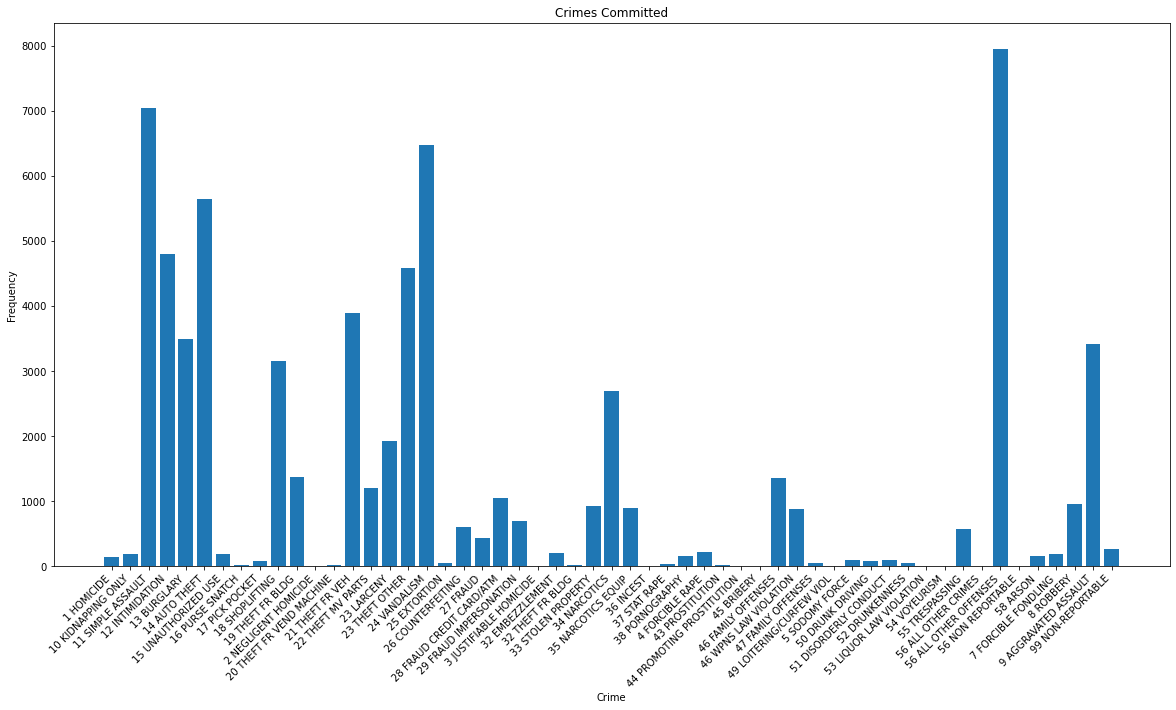

In [222]:
plt.figure(figsize=(20,10))
plt.bar(Louisville_Crimes_df.index, Louisville_Crimes_df.values)
plt.xticks(rotation=45, ha="right")
plt.title("Crimes Committed")
plt.xlabel("Crime")
plt.ylabel("Frequency")

### This is a graph showing the number of occurences for each listed crime. I chose to use a bar graph to help contextualize the frequency with which some crimes occur as opposed to others. I didn't make any specific choices with the color pattern.

In [223]:
Louisville_Murders = (
    LMPD_Analytics[LMPD_Analytics["offense_classification"] == "1 HOMICIDE"]
    .groupby("offense_classification")
    .size()
    .reset_index(name="count")
)

Louisville_Murders

,offense_classification,count
0,1 HOMICIDE,153


In [224]:
Louisville_Bribery = (
    LMPD_Analytics[LMPD_Analytics["offense_classification"] == "45 BRIBERY"]
    .groupby("offense_classification")
    .size()
    .reset_index(name="count")
)

Louisville_Bribery

,offense_classification,count
0,45 BRIBERY,3


In [225]:
Louisville_Embezzlement = (
    LMPD_Analytics[LMPD_Analytics["offense_classification"] == "32 EMBEZZLEMENT"]
    .groupby("offense_classification")
    .size()
    .reset_index(name="count")
)

Louisville_Embezzlement

,offense_classification,count
0,32 EMBEZZLEMENT,209


In [226]:
Louisville_Arson = (
    LMPD_Analytics[LMPD_Analytics["offense_classification"] == "58 ARSON"]
    .groupby("offense_classification")
    .size()
    .reset_index(name="count")
)

Louisville_Arson

,offense_classification,count
0,58 ARSON,170


In [227]:
offenses = ["1 HOMICIDE", "45 BRIBERY", "32 EMBEZZLEMENT", "58 ARSON"]

Louisville_Crimes2 = LMPD_Analytics[LMPD_Analytics["offense_classification"].isin(offenses)].groupby("offense_classification").size().reset_index(name="count")

Louisville_Crimes2

,offense_classification,count
0,1 HOMICIDE,153
1,32 EMBEZZLEMENT,209
2,45 BRIBERY,3
3,58 ARSON,170


Text(0.5, 1.0, 'Assorted Crimes in Louisville')

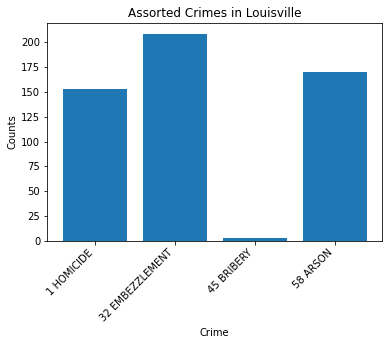

In [228]:
plt.bar(Louisville_Crimes2["offense_classification"], Louisville_Crimes2["count"])
plt.xlabel("Crime")
plt.ylabel("Counts")
plt.xticks(rotation=45, ha="right")
plt.title("Assorted Crimes in Louisville")


### Truthfully, the crimes of homicide, embezzlement, bribery, and arson weren't completely random. I chose homicide and arson because they're very visible crimes that often make headlines, as a result I was naturally curious to see just how often they actually occur based on what's been reported. I chose the crimes of embezzlement and bribery because even though they can "slide under the radar" they can do irreparable damage. Especially if the amount of money in question is exorbitant.

In [229]:
offenses = ["11 SIMPLE ASSAULT", "24 VANDALISM", "14 AUTO THEFT"]

Gotham = LMPD_Analytics[LMPD_Analytics["offense_classification"].isin(offenses)].groupby("offense_classification").size().reset_index(name="count")

Gotham

,offense_classification,count
0,11 SIMPLE ASSAULT,7266
1,14 AUTO THEFT,5789
2,24 VANDALISM,6623


Text(0.5, 1.0, 'Highest Specific Crimes in Louisville')

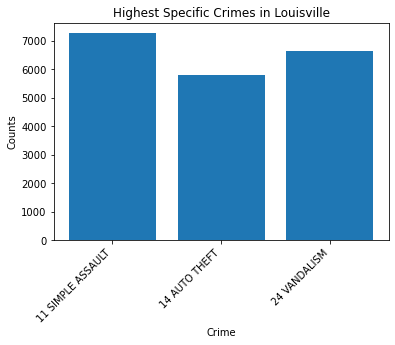

In [230]:
plt.bar(Gotham["offense_classification"], Gotham["count"])
plt.xlabel("Crime")
plt.ylabel("Counts")
plt.xticks(rotation=45, ha="right")
plt.title("Highest Specific Crimes in Louisville")

### I picked simple assault, auto theft, and vandalism because these are the specific crimes that had the highest reported occurences in the data. I chose a simple bar graph to make it easy to understand to any potential audiences who may view the data.

In [231]:
LMPD_Timelines = LMPD_Analytics.groupby("date_occurred")["date_reported"].value_counts()

LMPD_Timelines

date_occurred        date_reported      
2024-01-01 05:00:00  2024-01-01 05:00:00    12
                     2023-11-16 16:20:00     2
                     2024-01-23 17:08:00     2
                     2024-01-01 16:02:00     1
                     2024-01-01 17:26:00     1
                                            ..
2025-01-01 04:30:00  2025-01-01 16:41:00     1
                     2025-01-02 18:11:00     1
2025-01-01 04:45:00  2025-01-01 04:45:00     2
2025-01-01 04:50:00  2025-01-01 04:50:00     1
                     2025-01-01 06:05:00     1
Name: date_reported, Length: 53273, dtype: int64

In [232]:
LMPD_Analytics.head()

,incident_number,date_reported,date_occurred,badge_id,offense_classification,offense_code_name,nibrs_code,nibrs_group_name,was_offense_completed,lmpd_division,lmpd_beat,location_category,block_address,city,zip_code,ObjectId,report_delay_days
0,LMPD25147130,2025-12-10 15:57:00,2024-02-20 05:00:00,8701.0,19 THEFT FR BLDG,"TBUT OR DISP FROM BUILDING $1,000 < $10,000 51...",23D,A,YES,8TH DIVISION,812,RESIDENCE/HOME,5000 BLOCK CLIFFWOOD RD,LOUISVILLE,40222,1,659.0
1,LMPD25144947,2025-12-05 17:28:00,2024-11-16 05:00:00,8701.0,29 FRAUD IMPERSONATION,THEFT OF IDENTITY OF ANOTHER WITHOUT CONSENT 5...,26C,A,YES,4TH DIVISION,424,RESIDENCE/HOME,500 BLOCK LONGFIELD AVE,LOUISVILLE,40215,2,384.0
2,LMPD25140113,2025-11-24 04:22:00,2024-07-09 04:00:00,8631.0,29 FRAUD IMPERSONATION,THEFT OF IDENTITY OF ANOTHER WITHOUT CONSENT 5...,26C,A,YES,8TH DIVISION,824,RESIDENCE/HOME,100 BLOCK LA FONTENAY DR,DOUGLASS HILLS,40223,3,503.0
3,LMPD25139843,2025-11-23 14:37:00,2024-11-15 21:00:00,8560.0,14 AUTO THEFT,"TBUT OR DISP AUTO $1,000 < $10,000 514.030 241...",240,A,YES,2ND DIVISION,223,HIGHWAY/ ROAD/ ALLEY/ STREET/ SIDEWALK,1300 BLOCK S 26TH ST,LOUISVILLE,40210,4,372.0
4,LMPD25020252,2025-02-24 20:52:00,2024-12-19 03:51:00,8646.0,18 SHOPLIFTING,TBUT OR DISP SHOPLIFTING 514.030 24230 23C,23C,A,YES,3RD DIVISION,315,GROCERY/ SUPERMARKET,9900 BLOCK DIXIE HWY,LOUISVILLE,40272,5,67.0


In [233]:
LMPD_Analytics.columns
LMPD_Analytics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70776 entries, 0 to 70775
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   incident_number         70776 non-null  object        
 1   date_reported           70768 non-null  datetime64[ns]
 2   date_occurred           70776 non-null  datetime64[ns]
 3   badge_id                70771 non-null  float64       
 4   offense_classification  70645 non-null  object        
 5   offense_code_name       70774 non-null  object        
 6   nibrs_code              70776 non-null  object        
 7   nibrs_group_name        70776 non-null  object        
 8   was_offense_completed   70776 non-null  object        
 9   lmpd_division           70531 non-null  object        
 10  lmpd_beat               70495 non-null  object        
 11  location_category       70735 non-null  object        
 12  block_address           69663 non-null  object

In [234]:
LMPD_Analytics['incident_number'].unique()


array(['LMPD25147130', 'LMPD25144947', 'LMPD25140113', ...,
       'LMPD23109383', 'LMPD23109575', 'LMPD23107772'], dtype=object)

In [235]:
LMPD_Analytics['date_reported'].unique()


array(['2025-12-10T15:57:00.000000000', '2025-12-05T17:28:00.000000000',
       '2025-11-24T04:22:00.000000000', ...,
       '2023-11-09T13:11:00.000000000', '2023-11-08T23:00:00.000000000',
       '2023-11-05T19:35:00.000000000'], dtype='datetime64[ns]')

In [236]:
LMPD_Analytics['date_occurred'].unique()


array(['2024-02-20T05:00:00.000000000', '2024-11-16T05:00:00.000000000',
       '2024-07-09T04:00:00.000000000', ...,
       '2024-04-30T17:37:00.000000000', '2024-02-09T18:20:00.000000000',
       '2024-10-05T01:47:00.000000000'], dtype='datetime64[ns]')

In [237]:
LMPD_Analytics['badge_id'].unique()


array([  8701.,   8631.,   8560.,   8646.,   8544.,   8358.,   8643.,
         4354.,   8584.,   7269.,   5237.,   5067.,   5427.,   8630.,
         8499.,   5468.,   7283.,   8665.,   8708.,   8659.,   8585.,
         8185.,   7235.,   8611.,   8064.,   5522.,   5388.,   5663.,
         8454.,   5344.,   5263.,   2413.,   5158.,   5596.,   7427.,
         7004.,   5033.,   8661.,   8373.,   5286.,   6129.,   7205.,
         7035.,   8402.,   5349.,   5247.,   5249.,   7340.,   5186.,
         7371.,   7288.,   5135.,   6028.,   2469.,   7090.,   5258.,
         8173.,   5646.,   2489.,   7793.,   7080.,   5519.,   2623.,
         5606.,   5107.,   5104.,   5571.,   6311.,   7905.,   5144.,
         5312.,   5536.,   8592.,   5211.,   7962.,   5433.,   5112.,
         5218.,   7298.,   5233.,   9199.,   5319.,   5267.,   5471.,
         7632.,   7244.,   7472.,   7984.,   5652.,   5399.,   8644.,
         5410.,   7900.,   5615.,   5654.,   5330.,   7232.,   5332.,
         5439.,   74

In [238]:
LMPD_Analytics['offense_classification'].unique()

array(['19 THEFT FR BLDG', '29 FRAUD IMPERSONATION', '14 AUTO THEFT',
       '18 SHOPLIFTING', '23 THEFT OTHER', '28 FRAUD CREDIT CARD/ATM',
       '12 INTIMIDATION', '56 ALL OTHER OFFENSES', '13 BURGLARY',
       '22 THEFT MV PARTS', '32 EMBEZZLEMENT', '4 FORCIBLE RAPE',
       '24 VANDALISM', '43 PROSTITUTION', '26 COUNTERFEITING',
       '21 THEFT FR VEH', '46 FAMILY OFFENSES', '36 INCEST',
       '37 STAT RAPE', '5 SODOMY FORCE', '7 FORCIBLE FONDLING',
       '38 PORNOGRAPHY', nan, '9 AGGRAVATED ASSAULT',
       '15 UNAUTHORIZED USE', '34 NARCOTICS', '33 STOLEN PROPERTY',
       '23 LARCENY', '27 FRAUD', '46 WPNS LAW VIOLATION',
       '11 SIMPLE ASSAULT', '32 THEFT FR BLDG', '1 HOMICIDE',
       '35 NARCOTICS EQUIP', '55 TRESPASSING', '8 ROBBERY',
       '99 NON-REPORTABLE', '10 KIDNAPPING ONLY',
       '3 JUSTIFIABLE HOMICIDE', '20 THEFT FR VEND MACHINE',
       '51 DISORDERLY CONDUCT', '52 DRUNKENNESS', '50 DRUNK DRIVING',
       '56 ALL OTHER CRIMES', '58 ARSON', '47 FAMILY OFF

In [239]:
LMPD_Analytics['offense_code_name'].unique()

array(['TBUT OR DISP FROM BUILDING $1,000 < $10,000 514.030 24162 23D',
       'THEFT OF IDENTITY OF ANOTHER WITHOUT CONSENT 514.160 23310 26C',
       'TBUT OR DISP AUTO $1,000 < $10,000 514.030 24112 240',
       'TBUT OR DISP SHOPLIFTING 514.030 24230 23C',
       'THEFT BY DECEPTION INCLUDING COLD CHECKS $1,000 < $10,000 514.040(8)(b) 71287 23H',
       'THEFT BY DECEPTION INCLUDING COLD CHECKS $10,000 OR MORE 514.040(8)(c) 71289 23H',
       'FRAUDULENT USE OF A CREDIT CARD > $10,000 434.650(1)(B)(4) 71206 26B',
       'TBUT OR DISP FROM BUILDING 514.030 24160 23D',
       'HARASSMENT (NO PHYSICAL CONTACT) 525.070 02405 13C',
       'UNLAWFUL ACCESS TO COMPUTER-1ST DEGREE 434.845 51260 90Z',
       'TBUT OR DISP FIREARM 514.030 23100 23H',
       'BURGLARY - 3RD DEGREE 511.040 22062 220',
       'FRAUDULENT USE OF A CREDIT CARD $1000 < $10,000 434.650(1)(B)(2) 71204 26B',
       'TERRORISTIC THREATENING 3RD DEGREE 508.080 00822 13C',
       'THEFT OF MOTOR VEHICLE REGISTRATION PLA

In [240]:
LMPD_Analytics['nibrs_code'].unique()


array(['23D', '26C', '240', '23C', '23H', '26B', '13C', '26G', '220',
       '23G', '270', '11A', '90Z', '290', '64B', '250', '23F', '90F',
       '36A', '999', '13A', '720', '35A', '280', '26A', '520', '13B',
       '11D', '11B', '370', '09A', '35B', '90J', '120', '36B', '100',
       '09C', '23E', '90C', '90E', '90D', '200', '23A', '90H', '210',
       '23B', '90B', '09B', '510', '90G', '64A', '40B', '26F'],
      dtype=object)

In [241]:
LMPD_Analytics['nibrs_group_name'].unique()


array(['A', 'B'], dtype=object)

In [242]:
LMPD_Analytics['lmpd_division'].unique()


array(['8TH DIVISION', '4TH DIVISION', '2ND DIVISION', '3RD DIVISION',
       '1ST DIVISION', '6TH DIVISION', '7TH DIVISION', '5TH DIVISION',
       nan, 'CAL', 'OOJ', 'WEST BUECHEL', 'JEFFERSONTOWN', 'MIDDLETOWN',
       'SHIVELY', 'ST MATTHEWS', 'LYNDON', 'INDIAN HILLS', 'AUDUBON PARK',
       'ANCHORAGE', 'LMPD', 'PROSPECT', 'OLDHAM'], dtype=object)

In [243]:
LMPD_Analytics['lmpd_beat'].unique()

array(['812', '424', '824', '223', '315', '111', '323', '625', '225',
       '736', '735', '412', '322', '711', '512', '316', '112', '815',
       '331', '423', '712', '411', nan, '334', '724', '236', '525', '811',
       '234', '624', '514', '135', '123', '513', '612', '611', '613',
       '521', '823', '134', '723', '211', '436', 'CAL', 'OOJ', 'WB',
       'JTN', '212', 'MTN', '450', '435', '1', 'SHV', 'STM', 'LYND',
       'INH', 'AUD', 'ANC', 'PRO', 'OLD', 'IH'], dtype=object)

In [244]:
LMPD_Analytics['location_category'].unique()

array(['RESIDENCE/HOME', 'HIGHWAY/ ROAD/ ALLEY/ STREET/ SIDEWALK',
       'GROCERY/ SUPERMARKET', 'OTHER RESIDENCE (APARTMENT/CONDO)',
       'CYBERSPACE', 'RENTAL STORAGE FACILITY',
       'CHURCH/SYNAGOGUE/TEMPLE/MOSQUE', 'AUTO DEALERSHIP NEW/USED',
       'BAR/NIGHTCLUB', 'PARKING/ DROP LOT/ GARAGE',
       'COMMERCIAL/OFFICE BUILDING', 'DEPARTMENT/DISCOUNT STORE',
       'OTHER/UNKNOWN', 'BANK/SAVINGS AND LOAN', 'HOTEL/ MOTEL/ ETC.',
       "DRUG STORE/DOCTOR'S OFFICE/HOSPITAL", 'SPECIALTY STORE',
       'SCHOOL - ELEMENTARY/SECONDARY', 'LIQUOR STORE', 'INDUSTRIAL SITE',
       'SHELTER - MISSION/ HOMELESS', 'RESTAURANT',
       'NON-ATTACHED RESD GARAGE/SHED/BULD', 'CONSTRUCTION SITE',
       'ARENA/STADIUM/FAIRGROUNDS/COLISEUM', 'AIR/BUS/TRAIN TERMINAL',
       'CONVENIENCE STORE', 'DAYCARE FACILITY', 'SHOPPING MALL',
       'SERVICE/GAS STATION',
       'JAIL/PRISON/PENITENTIARY/CORRECTIONS FACILITY',
       'PARK/ PLAYGROUND', 'FIELD/WOODS', 'GOVERNMENT/ PUBLIC BUILDING',
     

In [245]:
LMPD_Analytics['city'].unique()

array(['LOUISVILLE', 'DOUGLASS HILLS', 'ROLLING HILLS', 'FRANKFORT',
       'RICHLAWN', 'LANGDON PLACE', 'FOREST HILLS', 'SHEPHERDSVILLE',
       'WEST BUECHEL', 'JEFFERSONTOWN', 'HURSTBOURNE ACRES', 'MIDDLETOWN',
       'WINDY HILLS', 'ATLANTA', 'LYNNVIEW',
       'LOUISVILLE-JEFFERSON COUNTY', 'WATTERSON PARK', 'WEST SPENCER',
       'BLUE RIDGE MANOR', 'PLANTATION', 'SHIVELY', 'BARBOURMEADE',
       'ST. REGIS PARK', 'HILLVIEW', 'WESTWOOD', 'MEADOW VALE',
       'RIVERWOOD', 'MOCKINGBIRD VALLEY', 'WOODLAND HILLS',
       'SPRING VALLEY', 'NORTHFIELD', 'COLDSTREAM', 'WORTHINGTON HILLS',
       'CREEKSIDE', 'ST MATTHEWS', 'WELLINGTON', 'GREEN SPRING',
       'GLENVIEW', 'DRUID HILLS', 'FINCASTLE', 'SPRING MILL',
       'BROWNSBORO FARM', 'FORDSVILLE', 'FAIRDALE', 'HURSTBOURNE',
       'ST. MATTHEWS', 'BELLEMEADE', 'LINCOLNSHIRE', 'HOLLYVILLA',
       'GOOSE CREEK', 'WOODLAWN PARK', 'NORWOOD', 'LYNDON',
       'MEADOWVIEW ESTATES', 'MANOR CREEK', 'HOLLOW CREEK',
       'HERITAGE CREEK'

In [246]:
LMPD_Analytics['zip_code'].unique()

array(['40222', '40215', '40223', '40210', '40272', '40212', '40214',
       '40220', '40211', '40219', '40203', '40291', '40118', '40204',
       '40242', '40218', '40216', '40601', '40258', '40208', '40229',
       '40207', '40241', '40245', '40299', '40205', '40202', '40059',
       '40213', '40217', '40229 0000', '40206', '40243', '40228', '99999',
       '40165', '40209', '30339', '40013', '40299 0000', '40018', '40023',
       '40206-0000', '40207 0000', '40225', '40215 0000', '40177',
       '402140000', '40216 0000', '40025', '40210 0000', '40219-0000',
       '40210-0000', '40272 0000', '40041', '40217 0000', '402160000',
       '4021', '40212 0000', '40211 0000', '40228-0000', '40218 0000',
       '42701', '40031', '40065', '40291 0000', '40118 0000',
       '40272-0000', '40241-0000', '40206 0000', '40258 0000', nan,
       '40208 0000', '402110000', '40211-0000', '40228 0000',
       '40245 0000', '42539', '402910000', '40241 0000', '40214-0000',
       '40047', '40023 0000

In [247]:
LMPD_Analytics['ObjectId'].unique()

array([    1,     2,     3, ..., 70774, 70775, 70776], dtype=int64)

In [248]:
LMPD_Analytics['block_address'].unique()


array(['5000 BLOCK CLIFFWOOD RD', '500 BLOCK LONGFIELD AVE',
       '100 BLOCK LA FONTENAY DR', ..., '5600 BLOCK BRINSON DR',
       '1600 BLOCK WILLIAM E SUMMERS AVE', '400 BLOCK S HUBBARDS LN'],
      dtype=object)

In [249]:
LMPD_Analytics.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
70771    False
70772    False
70773    False
70774    False
70775    False
Length: 70776, dtype: bool

In [250]:
LMPD_Analytics.dtypes

incident_number                   object
date_reported             datetime64[ns]
date_occurred             datetime64[ns]
badge_id                         float64
offense_classification            object
offense_code_name                 object
nibrs_code                        object
nibrs_group_name                  object
was_offense_completed             object
lmpd_division                     object
lmpd_beat                         object
location_category                 object
block_address                     object
city                              object
zip_code                          object
ObjectId                           int64
report_delay_days                float64
dtype: object

In [251]:
LMPD_Analytics.isnull()

,incident_number,date_reported,date_occurred,badge_id,offense_classification,offense_code_name,nibrs_code,nibrs_group_name,was_offense_completed,lmpd_division,lmpd_beat,location_category,block_address,city,zip_code,ObjectId,report_delay_days
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70771,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
70772,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
70773,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
70774,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [252]:
LMPD_Analytics.isna()

,incident_number,date_reported,date_occurred,badge_id,offense_classification,offense_code_name,nibrs_code,nibrs_group_name,was_offense_completed,lmpd_division,lmpd_beat,location_category,block_address,city,zip_code,ObjectId,report_delay_days
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70771,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
70772,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
70773,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
70774,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [253]:
LMPD_Analytics['zip_code'].unique()

array(['40222', '40215', '40223', '40210', '40272', '40212', '40214',
       '40220', '40211', '40219', '40203', '40291', '40118', '40204',
       '40242', '40218', '40216', '40601', '40258', '40208', '40229',
       '40207', '40241', '40245', '40299', '40205', '40202', '40059',
       '40213', '40217', '40229 0000', '40206', '40243', '40228', '99999',
       '40165', '40209', '30339', '40013', '40299 0000', '40018', '40023',
       '40206-0000', '40207 0000', '40225', '40215 0000', '40177',
       '402140000', '40216 0000', '40025', '40210 0000', '40219-0000',
       '40210-0000', '40272 0000', '40041', '40217 0000', '402160000',
       '4021', '40212 0000', '40211 0000', '40228-0000', '40218 0000',
       '42701', '40031', '40065', '40291 0000', '40118 0000',
       '40272-0000', '40241-0000', '40206 0000', '40258 0000', nan,
       '40208 0000', '402110000', '40211-0000', '40228 0000',
       '40245 0000', '42539', '402910000', '40241 0000', '40214-0000',
       '40047', '40023 0000

In [254]:
Local_Crimes = LMPD_Analytics.groupby("zip_code")["offense_classification"].value_counts()

Local_Crimes

zip_code  offense_classification  
0         4 FORCIBLE RAPE             1
30339     28 FRAUD CREDIT CARD/ATM    1
30349     56 ALL OTHER OFFENSES       1
33054     14 AUTO THEFT               1
40004     33 STOLEN PROPERTY          1
                                     ..
99999     43 PROSTITUTION             2
          23 THEFT OTHER              1
          27 FRAUD                    1
          33 STOLEN PROPERTY          1
          46 FAMILY OFFENSES          1
Name: offense_classification, Length: 1652, dtype: int64

Text(0, 0.5, 'Frequency')

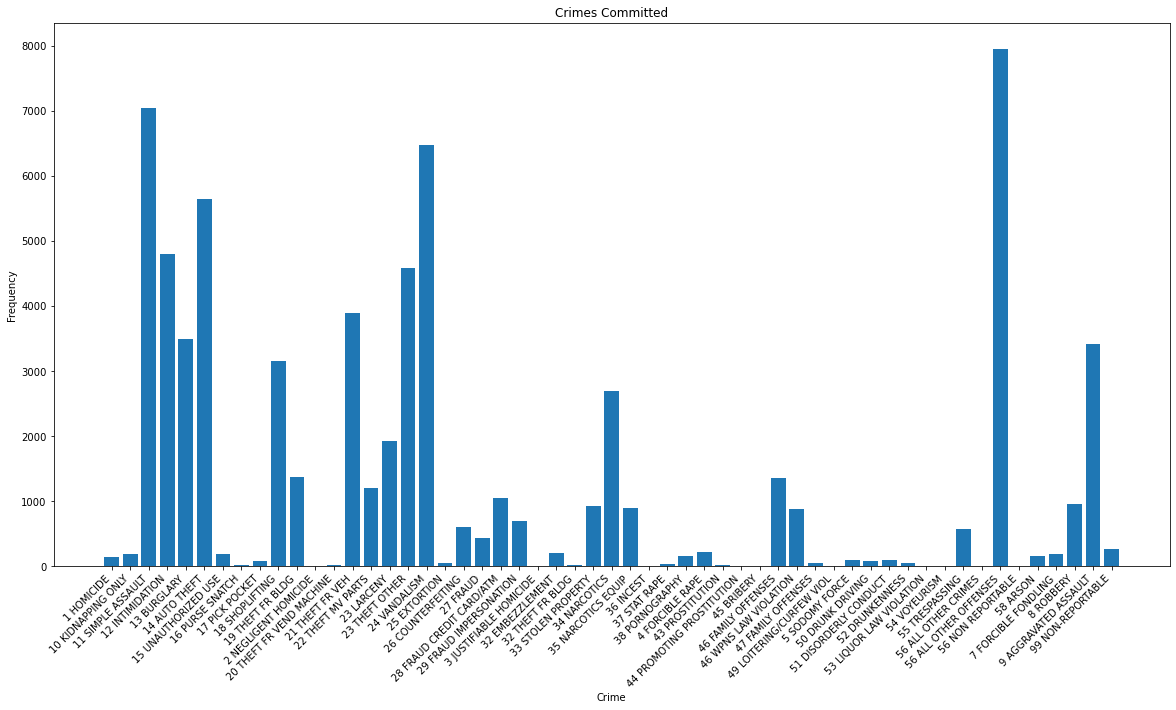

In [255]:
plt.figure(figsize=(20,10))
plt.bar(Louisville_Crimes_df.index, Louisville_Crimes_df.values)
plt.xticks(rotation=45, ha="right")
plt.title("Crimes Committed")
plt.xlabel("Crime")
plt.ylabel("Frequency")

In [256]:
offenses = ["11 SIMPLE ASSAULT", "24 VANDALISM", "14 AUTO THEFT", "12 INTIMIDATION", "13 BURGLARY"]

Louisville_Crimes2 = LMPD_Analytics[LMPD_Analytics["offense_classification"].isin(offenses)].groupby("offense_classification").size().reset_index(name="count")

Louisville_Crimes2

,offense_classification,count
0,11 SIMPLE ASSAULT,7266
1,12 INTIMIDATION,4946
2,13 BURGLARY,3556
3,14 AUTO THEFT,5789
4,24 VANDALISM,6623


Text(0, 0.5, 'Reported Occurences')

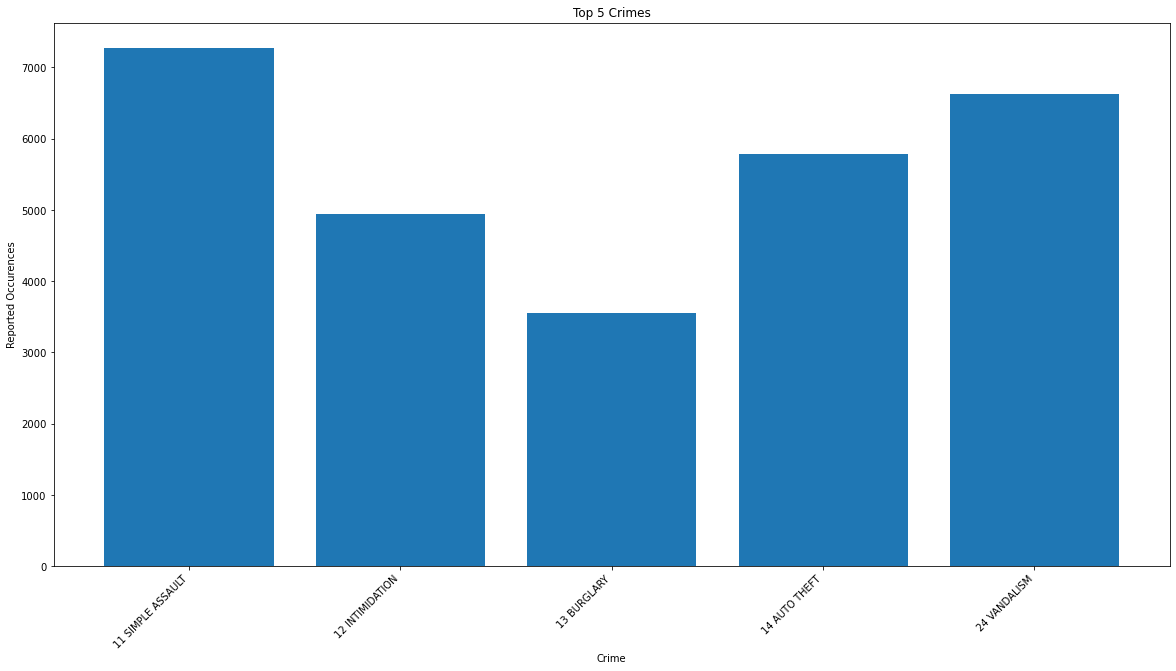

In [257]:
plt.figure(figsize=(20,10))
plt.bar(Louisville_Crimes2["offense_classification"], Louisville_Crimes2["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 5 Crimes")
plt.xlabel("Crime")
plt.ylabel("Reported Occurences")

### The goal of this graph is to find out which crimes were reported the most often. I picked these crimes specific crimes because they had the highest occurrences.

In [258]:
Local_Crimes = LMPD_Analytics.groupby("zip_code")["offense_classification"].value_counts()

Local_Crimes

zip_code  offense_classification  
0         4 FORCIBLE RAPE             1
30339     28 FRAUD CREDIT CARD/ATM    1
30349     56 ALL OTHER OFFENSES       1
33054     14 AUTO THEFT               1
40004     33 STOLEN PROPERTY          1
                                     ..
99999     43 PROSTITUTION             2
          23 THEFT OTHER              1
          27 FRAUD                    1
          33 STOLEN PROPERTY          1
          46 FAMILY OFFENSES          1
Name: offense_classification, Length: 1652, dtype: int64

In [259]:
Local_Crimes = LMPD_Analytics.groupby("zip_code")["offense_classification"].value_counts().sort_values(ascending=False)

Local_Crimes

zip_code  offense_classification
40211     56 ALL OTHER OFFENSES     620
40215     56 ALL OTHER OFFENSES     582
40203     56 ALL OTHER OFFENSES     574
40202     21 THEFT FR VEH           553
40212     56 ALL OTHER OFFENSES     546
                                   ... 
40217     37 STAT RAPE                1
          38 PORNOGRAPHY              1
          45 BRIBERY                  1
          47 FAMILY OFFENSES          1
99999     46 FAMILY OFFENSES          1
Name: offense_classification, Length: 1652, dtype: int64

In [260]:
Louisville_Crimes = (
    LMPD_Analytics[LMPD_Analytics["city"] == "LOUISVILLE"]
    .groupby("offense_classification")
    .size()
    .reset_index(name="count")
)

Louisville_Crimes

,offense_classification,count
0,1 HOMICIDE,148
1,10 KIDNAPPING ONLY,195
2,11 SIMPLE ASSAULT,7044
3,12 INTIMIDATION,4800
4,13 BURGLARY,3487
5,14 AUTO THEFT,5640
6,15 UNAUTHORIZED USE,190
7,16 PURSE SNATCH,15
8,17 PICK POCKET,84
9,18 SHOPLIFTING,3157


In [261]:
Local_Crimes2 = (
    LMPD_Analytics
    .groupby("zip_code")["offense_classification"]
    .size()
    .sort_values(ascending=False)
)
Local_Crimes2

zip_code
40203         4986
40211         4828
40214         4686
40219         4667
40202         4121
              ... 
402220000        1
402230000        1
40228-0000       1
40228-1769       1
402160000        1
Name: offense_classification, Length: 145, dtype: int64

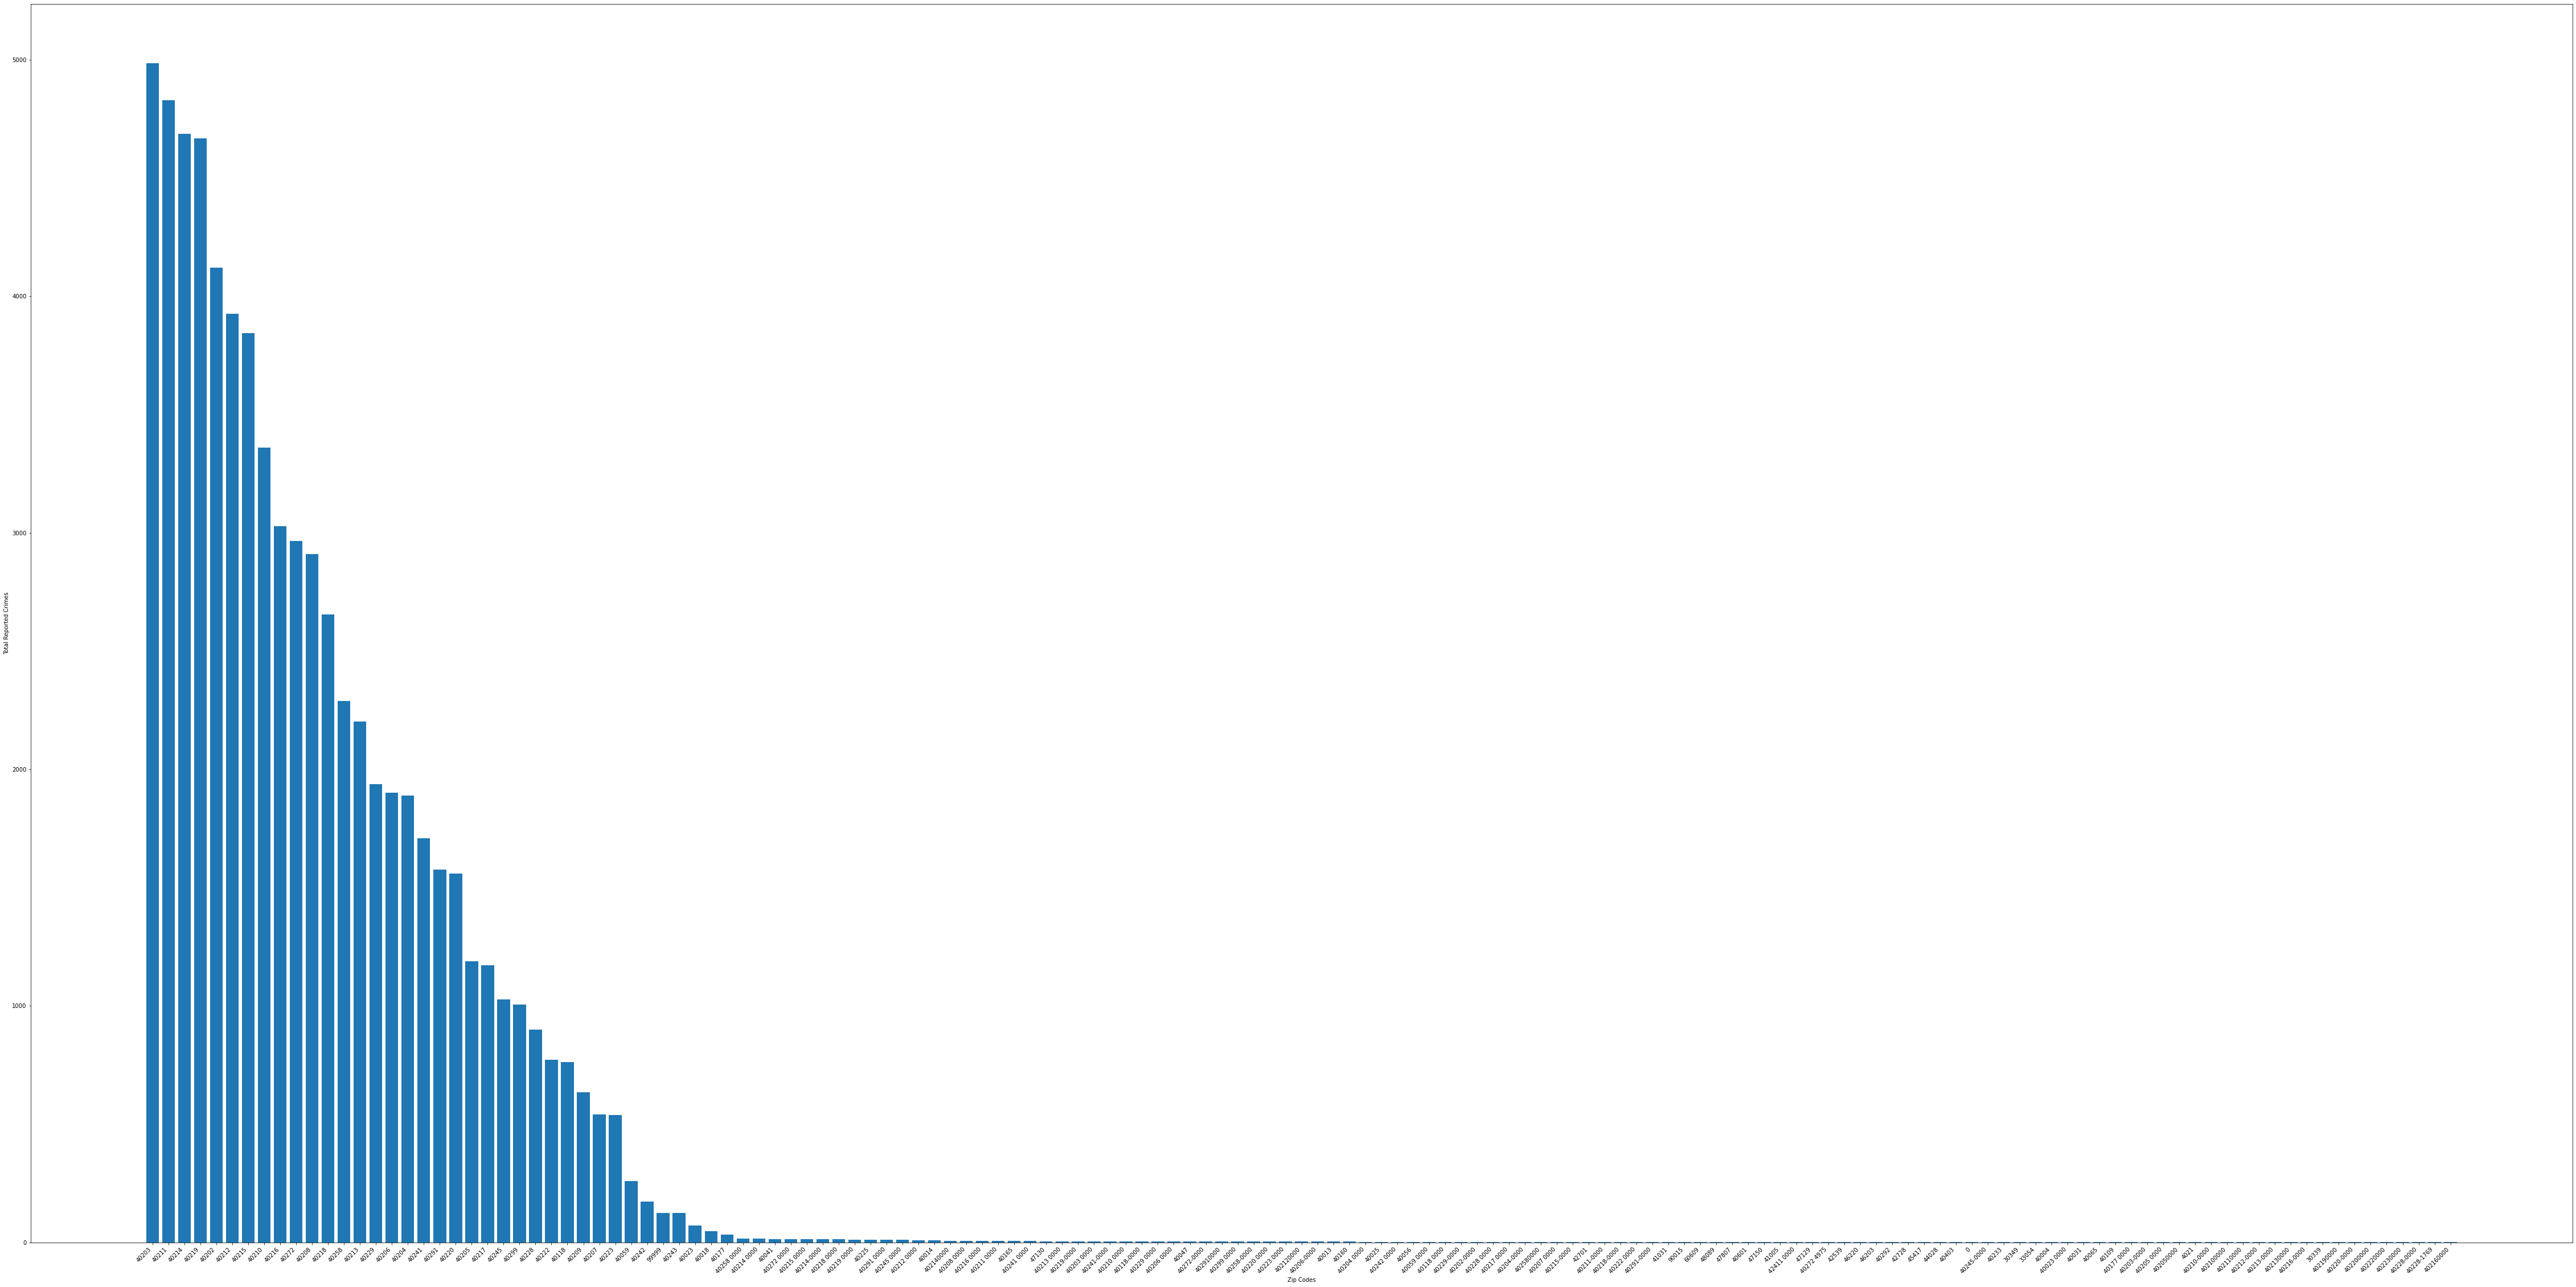

In [262]:
plt.figure(figsize=(80,40))
plt.bar(Local_Crimes2.index, Local_Crimes2.values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Zip Codes", )
plt.ylabel("Total Reported Crimes")
plt.tight_layout
plt.show()

### This graph is a visualization of crimes reported across all listed zip codes in the dataset. The crimes in this dataset is inclusive of a column referred to as "all other offenses". This particular visualization is not only misleading but woefully overwhelming. Despite my best efforts I couldn't get the font any smaller.

In [263]:
Local_Crimes2 = (
    LMPD_Analytics
    .groupby("zip_code")["offense_classification"]
    .size()
    .sort_values(ascending=False)
)

Local_Crimes2

zip_code
40203         4986
40211         4828
40214         4686
40219         4667
40202         4121
              ... 
402220000        1
402230000        1
40228-0000       1
40228-1769       1
402160000        1
Name: offense_classification, Length: 145, dtype: int64

In [264]:
Local_Crimes = (
    LMPD_Analytics
    .groupby(["zip_code", "offense_classification"])
    .size()
    .reset_index(name="count")
)

Local_Crimes

,zip_code,offense_classification,count
0,0,4 FORCIBLE RAPE,1
1,30339,28 FRAUD CREDIT CARD/ATM,1
2,30349,56 ALL OTHER OFFENSES,1
3,33054,14 AUTO THEFT,1
4,40004,33 STOLEN PROPERTY,1
...,...,...,...
1647,99999,46 FAMILY OFFENSES,1
1648,99999,5 SODOMY FORCE,7
1649,99999,56 ALL OTHER OFFENSES,3
1650,99999,7 FORCIBLE FONDLING,10


In [265]:
Homicides_By_Zip = (
    LMPD_Analytics[
        (LMPD_Analytics["offense_classification"] == "1 HOMICIDE") &
        (LMPD_Analytics["zip_code"].isin(zip_codes))
    ]
    .groupby("zip_code")
    .size()
    .sort_values(ascending=False)
    .head(5) #Chatgpt assisted
)

Homicides_By_Zip

zip_code
40210    26
40203    17
40211    14
40212    10
40202     4
dtype: int64

In [266]:
zip_codes = ["40210", "40203", "40211", "40212", "40202"]

In [267]:
Kill_zone = (
    LMPD_Analytics[
        (LMPD_Analytics["offense_classification"] == "1 HOMICIDE") &
        (LMPD_Analytics["zip_code"].isin(zip_codes))
    ]
    .groupby("zip_code")
    .size()
    .reindex(zip_codes, fill_value=0)
)

Kill_zone

zip_code
40210    26
40203    17
40211    14
40212    10
40202     4
dtype: int64

In [268]:
Burglaries_By_Zip = (
    LMPD_Analytics[
        (LMPD_Analytics["offense_classification"] == "13 BURGLARY") &
        (LMPD_Analytics["zip_code"].isin(zip_codes))
    ]
    .groupby("zip_code")
    .size()
    .sort_values(ascending=False)
    .head(5)
)

Burglaries_By_Zip

zip_code
40203    280
40211    275
40212    181
40202    158
40210    156
dtype: int64

In [269]:
zip_codes = ["40203", "40211", "40212", "40202", "40210"]

In [270]:
Den_of_Thieves = (
    LMPD_Analytics[
        (LMPD_Analytics["offense_classification"] == "13 BURGLARY") &
        (LMPD_Analytics["zip_code"].isin(zip_codes))
    ]
    .groupby("zip_code")
    .size()
    .reindex(zip_codes, fill_value=0)
)

Den_of_Thieves

zip_code
40203    280
40211    275
40212    181
40202    158
40210    156
dtype: int64

Text(0.5, 1.0, 'Burglaries by Zip Code')

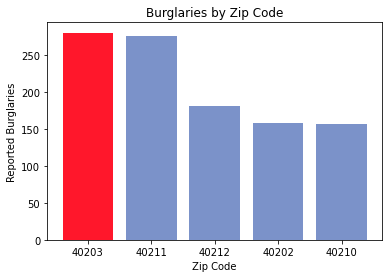

In [271]:
colors = ["#7b92c9"]*len(Kill_zone)
max_index = Den_of_Thieves.idxmax()
highlight_position = Den_of_Thieves.index.get_loc(max_index)
colors[highlight_position] = "#ff172b"

plt.bar(
    Den_of_Thieves.index,
    Den_of_Thieves.values,
    color = colors
)

plt.xlabel("Zip Code")
plt.ylabel("Reported Burglaries")
plt.title("Burglaries by Zip Code")

### This is a graph showing the different number of reported burglaries across assorted zip codes. I picked burglary because out of all forms of theft, burglaries appear to have been reported the most.

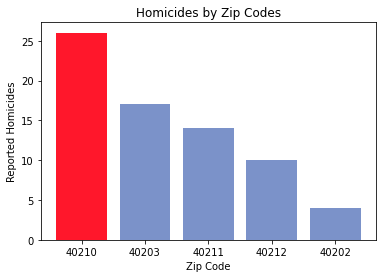

In [272]:
colors = ["#7b92c9"]*len(Kill_zone)
max_index = Kill_zone.idxmax()
highlight_position = Kill_zone.index.get_loc(max_index)
colors[highlight_position] = "#ff172b"

plt.bar(
    Kill_zone.index,
    Kill_zone.values,
    color=colors
)

plt.xlabel("Zip Code")
plt.ylabel("Reported Homicides")
plt.title("Homicides by Zip Codes")
plt.tight_layout
plt.show()

### This bar graph shows the different zip codes that had the highest reported rates of homicides. I used red to show which zip code had the highest rate of reported homicides. Whether more homicides actually occurred in this area or were simply reported more often remains a mystery.

In [273]:
Fight_Night = (
    LMPD_Analytics[
        (LMPD_Analytics["offense_classification"] == "11 SIMPLE ASSAULT") &
        (LMPD_Analytics["zip_code"].isin(zip_codes))
    ]
    .groupby("zip_code")
    .size()
    .reindex(zip_codes, fill_value=0)
)

Fight_Night

zip_code
40203    524
40211    509
40212    461
40202    352
40210    381
dtype: int64

Text(0.5, 1.0, 'Simple Assaults by Zip Code')

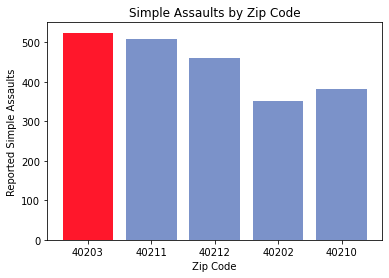

In [274]:
colors = ["#7b92c9"]*len(Kill_zone)
max_index = Fight_Night.idxmax()
highlight_position = Fight_Night.index.get_loc(max_index)
colors[highlight_position] = "#ff172b"

plt.bar(
    Fight_Night.index,
    Fight_Night.values,
    color = colors
)

plt.xlabel("Zip Code")
plt.ylabel("Reported Simple Assaults")
plt.title("Simple Assaults by Zip Code")

### This is a graph comparing simple assaults reported by different zip codes. I chose the crime of simple assaults because it's the one specific crime that had the highest reported occurrence according to the data.

In [275]:
LMPD_311_Analytics = pd.read_csv("..\Data\Louisville_Metro_KY_Metro_311_Service_Requets_2024_-8572044750753862362.csv")

LMPD_311_Analytics

c:\Users\zakm1\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3165: DtypeWarning: Columns (16) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,X,Y,service_request_id,requested_datetime,probyear,updated_datetime,closed_date,status_description,status_notes,source,...,description,agency_responsible,address,longitude,latitude,zip_code,council_district,ObjectId,x2,y2
0,NaN,NaN,SR-MTRO-24-046416,4/11/2024 4:00:00 AM,2024,NaN,NaN,OPEN,NaN,Call Center,...,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN,1,-9.544606e+06,4.619548e+06
1,NaN,NaN,SR-BAPT-24-089308,7/4/2024 4:00:00 AM,2024,7/10/2024 4:00:00 AM,7/10/2024 4:00:00 AM,CLOSED,NaN,NaN,...,NaN,NaN,922 GREENLEAF RD,-85.734067,38.204961,40213,10,2,-9.543873e+06,4.608420e+06
2,NaN,NaN,SR-STRT-24-016381,2/6/2024 5:00:00 AM,2024,2/6/2024 5:00:00 AM,2/6/2024 5:00:00 AM,CLOSED,NaN,NaN,...,several potholes along street by schools,NaN,1706 S 2ND ST 1,-85.759303,38.222700,40208,6,3,-9.546682e+06,4.610934e+06
3,NaN,NaN,SR-MTRO-24-068083,5/23/2024 4:00:00 AM,2024,NaN,NaN,OPEN,NaN,Call Center,...,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN,4,-9.544606e+06,4.619548e+06
4,NaN,NaN,SR-MISC-24-046800,4/12/2024 4:00:00 AM,2024,NaN,NaN,OPEN,NaN,Call Center,...,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN,5,-9.544606e+06,4.619548e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169593,NaN,NaN,SR-INTR-24-091992,7/10/2024 4:00:00 AM,2024,7/10/2024 4:00:00 AM,7/10/2024 4:00:00 AM,CLOSED,NaN,Call Center,...,THE CITIZEN REPORTS NO HOT WATER AND NOW THE W...,NaN,425 W ORMSBY AVE 607,-85.762182,38.233292,40203,6,169594,-9.547002e+06,4.612435e+06
169594,NaN,NaN,SR-GOVT-24-092520,7/10/2024 4:00:00 AM,2024,NaN,NaN,OPEN,NaN,Call Center,...,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN,169595,-9.544606e+06,4.619548e+06
169595,NaN,NaN,SR-STLT-24-092710,7/11/2024 4:00:00 AM,2024,7/11/2024 4:00:00 AM,7/11/2024 4:00:00 AM,CLOSED,NaN,Call Center,...,Street light out in the alley behind this prop...,Public Works Electrical Maint,1404 S 28TH ST,-85.801025,38.233806,40211,1,169596,-9.551326e+06,4.612508e+06
169596,NaN,NaN,SR-INTR-24-059424,5/7/2024 4:00:00 AM,2024,11/25/2024 5:00:00 AM,11/25/2024 5:00:00 AM,CLOSED,NaN,Call Center,...,THE CITIZEN STATES THAT THE HOT WATER TANK IS ...,NaN,4300 BRECKENRIDGE LN 1,-85.626577,38.185436,40218,2,169597,-9.531907e+06,4.605655e+06


In [276]:
LMPD_311_Analytics.head()

,X,Y,service_request_id,requested_datetime,probyear,updated_datetime,closed_date,status_description,status_notes,source,...,description,agency_responsible,address,longitude,latitude,zip_code,council_district,ObjectId,x2,y2
0,NaN,NaN,SR-MTRO-24-046416,4/11/2024 4:00:00 AM,2024,NaN,NaN,OPEN,NaN,Call Center,...,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN,1,-9.544606e+06,4.619548e+06
1,NaN,NaN,SR-BAPT-24-089308,7/4/2024 4:00:00 AM,2024,7/10/2024 4:00:00 AM,7/10/2024 4:00:00 AM,CLOSED,NaN,NaN,...,NaN,NaN,922 GREENLEAF RD,-85.734067,38.204961,40213,10,2,-9.543873e+06,4.608420e+06
2,NaN,NaN,SR-STRT-24-016381,2/6/2024 5:00:00 AM,2024,2/6/2024 5:00:00 AM,2/6/2024 5:00:00 AM,CLOSED,NaN,NaN,...,several potholes along street by schools,NaN,1706 S 2ND ST 1,-85.759303,38.222700,40208,6,3,-9.546682e+06,4.610934e+06
3,NaN,NaN,SR-MTRO-24-068083,5/23/2024 4:00:00 AM,2024,NaN,NaN,OPEN,NaN,Call Center,...,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN,4,-9.544606e+06,4.619548e+06
4,NaN,NaN,SR-MISC-24-046800,4/12/2024 4:00:00 AM,2024,NaN,NaN,OPEN,NaN,Call Center,...,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN,5,-9.544606e+06,4.619548e+06


In [277]:
LMPD_311_Analytics.columns
LMPD_311_Analytics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169598 entries, 0 to 169597
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   X                   0 non-null       float64
 1   Y                   0 non-null       float64
 2   service_request_id  169598 non-null  object 
 3   requested_datetime  169598 non-null  object 
 4   probyear            169598 non-null  int64  
 5   updated_datetime    117983 non-null  object 
 6   closed_date         105941 non-null  object 
 7   status_description  169598 non-null  object 
 8   status_notes        0 non-null       float64
 9   source              106631 non-null  object 
 10  service_name        169598 non-null  object 
 11  description         95286 non-null   object 
 12  agency_responsible  20204 non-null   object 
 13  address             110356 non-null  object 
 14  longitude           169598 non-null  float64
 15  latitude            169598 non-nul

In [278]:
LMPD_311_Analytics['requested_datetime'].unique()


array(['4/11/2024 4:00:00 AM', '7/4/2024 4:00:00 AM',
       '2/6/2024 5:00:00 AM', '5/23/2024 4:00:00 AM',
       '4/12/2024 4:00:00 AM', '5/24/2024 4:00:00 AM',
       '2/15/2024 5:00:00 AM', '7/10/2024 4:00:00 AM',
       '4/15/2024 4:00:00 AM', '8/29/2024 4:00:00 AM',
       '2/8/2024 5:00:00 AM', '10/4/2024 4:00:00 AM',
       '7/11/2024 4:00:00 AM', '5/28/2024 4:00:00 AM',
       '7/24/2024 4:00:00 AM', '3/4/2024 5:00:00 AM',
       '7/9/2024 4:00:00 AM', '10/7/2024 4:00:00 AM',
       '7/26/2024 4:00:00 AM', '6/12/2024 4:00:00 AM',
       '8/30/2024 4:00:00 AM', '10/8/2024 4:00:00 AM',
       '2/20/2024 5:00:00 AM', '10/9/2024 4:00:00 AM',
       '5/29/2024 4:00:00 AM', '7/15/2024 4:00:00 AM',
       '12/29/2024 5:00:00 AM', '7/5/2024 4:00:00 AM',
       '8/31/2024 4:00:00 AM', '4/16/2024 4:00:00 AM',
       '7/16/2024 4:00:00 AM', '7/8/2024 4:00:00 AM',
       '1/4/2024 5:00:00 AM', '3/20/2024 4:00:00 AM',
       '9/3/2024 4:00:00 AM', '12/30/2024 5:00:00 AM',
       '4/18/2024

In [279]:
LMPD_311_Analytics['closed_date'].unique()

array([nan, '7/10/2024 4:00:00 AM', '2/6/2024 5:00:00 AM',
       '2/15/2024 5:00:00 AM', '7/15/2024 4:00:00 AM',
       '4/15/2024 4:00:00 AM', '8/29/2024 4:00:00 AM',
       '9/29/2025 4:00:00 AM', '2/16/2024 5:00:00 AM',
       '3/4/2024 5:00:00 AM', '10/20/2025 4:00:00 AM',
       '10/7/2024 4:00:00 AM', '4/18/2024 4:00:00 AM',
       '3/27/2025 4:00:00 AM', '5/20/2025 4:00:00 AM',
       '9/23/2024 4:00:00 AM', '10/8/2024 4:00:00 AM',
       '2/23/2024 5:00:00 AM', '10/9/2024 4:00:00 AM',
       '5/29/2024 4:00:00 AM', '7/26/2024 4:00:00 AM',
       '1/3/2025 5:00:00 AM', '7/5/2024 4:00:00 AM',
       '8/31/2024 4:00:00 AM', '4/23/2024 4:00:00 AM',
       '7/8/2024 4:00:00 AM', '3/20/2024 4:00:00 AM',
       '12/30/2024 5:00:00 AM', '7/30/2024 4:00:00 AM',
       '7/17/2024 4:00:00 AM', '3/13/2024 4:00:00 AM',
       '3/28/2025 4:00:00 AM', '4/3/2025 4:00:00 AM',
       '5/5/2025 4:00:00 AM', '7/21/2025 4:00:00 AM',
       '11/8/2024 5:00:00 AM', '11/20/2024 5:00:00 AM',
       '1

In [280]:
LMPD_311_Analytics['zip_code'].unique()

array([nan, '40213', '40208', '40207', '40214', '40205', '40245', '40211',
       '40217', '40206', '40212', '40203', '40229', '40220', '40258',
       '40210', '40219', '40218', '40204', '40291', '40216', '40272',
       '40202', '40209', '40241', '40222', '40215', '40118', '40299',
       '40223', '40228', '40023', '40242', '40059', '40243', '40177',
       '40225', '40272-0000', '40041', '40212-0000', '40014', 40219.0,
       40218.0, 40203.0, 40205.0, 40212.0, 40211.0, 40208.0, 40206.0,
       40272.0, 40214.0, 40217.0, 40213.0, 40220.0, 40210.0, 40207.0,
       40023.0, 40215.0, 40059.0, 40258.0, 40245.0, 40299.0, 40216.0,
       40229.0, 40228.0, 40204.0, 40291.0, 40202.0, 40241.0, 40223.0,
       40222.0, 40242.0, 40118.0, 40209.0, 40243.0, 40225.0, 40177.0,
       40014.0, 40041.0, 40108.0, 402.0, '20204', '40214-0000'],
      dtype=object)

In [281]:
LMPD_311_Analytics["agency_responsible"].unique()

array([nan, 'APCD Community Compliance',
       'C&R Property Maintenance Enforcement', 'LMPD',
       'Louisville  Animal Services', 'Metro Parks',
       'Public Works Electrical Maint', 'Parking Authority River City',
       'C&R Vacant Lots Enforcement', 'Health Investigative',
       'Public Works Bulk Waste', 'Metro Call',
       'Public Works SWMS Enforcement', 'ABC Licensing',
       'MSD Construction Plan Reviewers',
       'Public Works Engineering Inspections', 'MSD Flood Plain',
       'Public Works Traffic Engineering',
       'Planning and Zoning Enforcement', 'Public Works Admin',
       'RCS Homeless Services Division', 'Public Works Roads - West',
       'Waterfront Development Corporation',
       'Louisville Parks and Recreation', 'Urban Forestry',
       'ABC Enforcement', 'APCD Industrial Compliance',
       'Public Works SWMS Admin', 'Public Works Engineering',
       'Public Works Roads - Central',
       'Public Works Permitting and Licensing', 'Emergency Servic

In [282]:
LMPD_311_Analytics.isna()

,X,Y,service_request_id,requested_datetime,probyear,updated_datetime,closed_date,status_description,status_notes,source,...,description,agency_responsible,address,longitude,latitude,zip_code,council_district,ObjectId,x2,y2
0,True,True,False,False,False,True,True,False,True,False,...,True,True,True,False,False,True,True,False,False,False
1,True,True,False,False,False,False,False,False,True,True,...,True,True,False,False,False,False,False,False,False,False
2,True,True,False,False,False,False,False,False,True,True,...,False,True,False,False,False,False,False,False,False,False
3,True,True,False,False,False,True,True,False,True,False,...,True,True,True,False,False,True,True,False,False,False
4,True,True,False,False,False,True,True,False,True,False,...,True,True,True,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169593,True,True,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
169594,True,True,False,False,False,True,True,False,True,False,...,True,True,True,False,False,True,True,False,False,False
169595,True,True,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
169596,True,True,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False


In [283]:
Request_Count = (
    LMPD_311_Analytics[LMPD_311_Analytics["agency_responsible"] == "LMPD"]
    .groupby("zip_code")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
    .head(6)
)

Request_Count

,zip_code,count
0,40214,258
1,40211,210
2,40215,198
3,40212,195
4,40214.0,184
5,40219,174


#### This shows that the top 6 zip codes with the highest number of metro 311 requests were 40214, 40211, 40215, 40212, 40214.0, and 40219. For the sake of visualizations I will be removing 40214.0. At this juncture I'm unable to explain the difference between 40214 and 40214.0. These are all requests that were handled by LMPD. ####

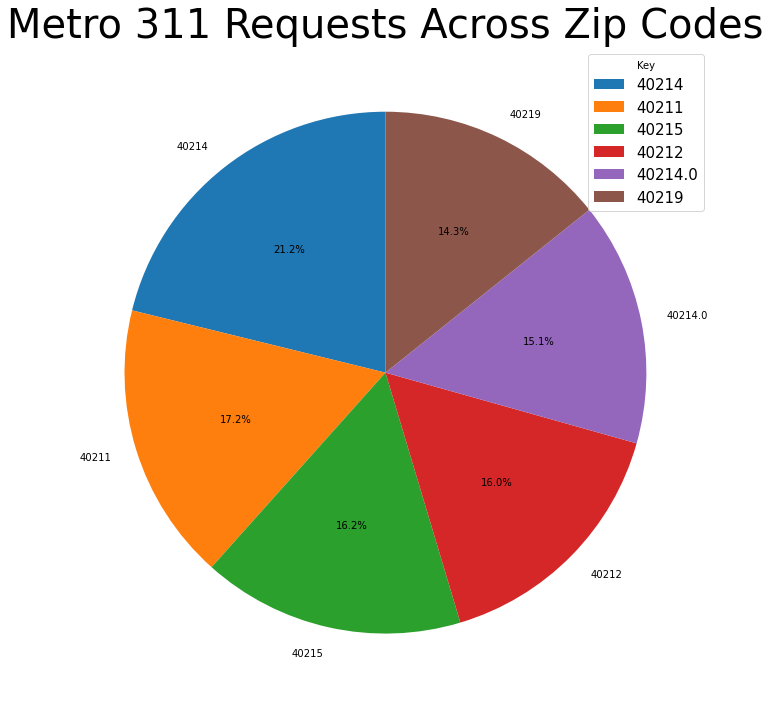

In [284]:
#Claude AI Assisted
plt.figure(figsize=(20,12))
plt.gcf().set_facecolor("white")
plt.pie(
    Request_Count["count"].values,
    labels=Request_Count["zip_code"].values,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Metro 311 Requests Across Zip Codes",
          fontsize=40)



plt.legend(
    labels = Request_Count["zip_code"],
    loc="upper right",
    title="Key",
    fontsize=15
)

plt.show()

### This pie chart is a visualization showing the different rates of reported 311 requests across the highest zip codes. ###

In [285]:
Agency_Count_40214= (
    LMPD_311_Analytics[LMPD_311_Analytics["zip_code"] == "40214"]
    .groupby("agency_responsible")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)

Agency_Count_40214

,agency_responsible,count
0,LMPD,258
1,Louisville Animal Services,148
2,C&R Property Maintenance Enforcement,123
3,Metro Parks,76
4,Public Works Electrical Maint,59
5,Parking Authority River City,25
6,MSD Construction Plan Reviewers,21
7,APCD Community Compliance,8
8,Public Works SWMS Enforcement,8
9,MSD Flood Plain,7


In [286]:
Agency_Count_40211 = (
    LMPD_311_Analytics[LMPD_311_Analytics["zip_code"] == "40211"]
    .groupby("agency_responsible")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)

Agency_Count_40211

,agency_responsible,count
0,Louisville Animal Services,241
1,LMPD,210
2,C&R Property Maintenance Enforcement,173
3,Public Works Electrical Maint,56
4,Metro Parks,35
5,APCD Community Compliance,31
6,MSD Flood Plain,29
7,Parking Authority River City,16
8,MSD Construction Plan Reviewers,14
9,Health Investigative,13


In [287]:
Agency_Count_40215 = (
    LMPD_311_Analytics[LMPD_311_Analytics["zip_code"] == "40215"]
    .groupby("agency_responsible")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)

Agency_Count_40215

,agency_responsible,count
0,LMPD,198
1,Louisville Animal Services,157
2,Parking Authority River City,110
3,C&R Property Maintenance Enforcement,98
4,Public Works Electrical Maint,56
5,Metro Parks,43
6,APCD Community Compliance,17
7,MSD Flood Plain,12
8,MSD Construction Plan Reviewers,11
9,Public Works Traffic Engineering,8


In [288]:
Agency_Count_40212 = (
    LMPD_311_Analytics[LMPD_311_Analytics["zip_code"] == "40212"]
    .groupby("agency_responsible")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)

Agency_Count_40212

,agency_responsible,count
0,LMPD,195
1,Louisville Animal Services,147
2,C&R Property Maintenance Enforcement,124
3,Parking Authority River City,41
4,Metro Parks,39
5,APCD Community Compliance,32
6,MSD Flood Plain,24
7,Public Works Electrical Maint,21
8,Public Works SWMS Enforcement,9
9,MSD Construction Plan Reviewers,5


In [289]:
Agency_Count_40219 = (
    LMPD_311_Analytics[LMPD_311_Analytics["zip_code"] == "40219"]
    .groupby("agency_responsible")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)

Agency_Count_40219

,agency_responsible,count
0,LMPD,174
1,Louisville Animal Services,114
2,C&R Property Maintenance Enforcement,64
3,Metro Parks,20
4,ABC Enforcement,12
5,Public Works Electrical Maint,12
6,APCD Community Compliance,12
7,MSD Flood Plain,10
8,ABC Licensing,8
9,Planning and Zoning Enforcement,8


In [290]:
Agency_Count_40208 = (
    LMPD_311_Analytics[LMPD_311_Analytics["zip_code"] == "40208"]
    .groupby("agency_responsible")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)

Agency_Count_40208

,agency_responsible,count
0,Parking Authority River City,165
1,Louisville Animal Services,83
2,C&R Property Maintenance Enforcement,72
3,Metro Parks,43
4,LMPD,30
5,Public Works Electrical Maint,21
6,MSD Flood Plain,15
7,Health Investigative,13
8,APCD Community Compliance,11
9,MSD Construction Plan Reviewers,10


### The tables above were generated to see which agency is responsible for responding to the zip codes with the highest amount of metro 311 requests. In each instance the group that had the highest response rate was LMPD. ###

In [ ]:
# Create a pie chart comparing simple assaults across zip codes
# Create a pie chart comparing metro across zip codes - Completed
# Think of questions I can ask that are answerable with the data provided
# Create a scatter plot of crimes vs zip codes
# Create a scatter plot of 311 requests vs zip codes
# Combine the scatter plots
# Use at least 3 Intermediate SQL queries (Module 4: Week 4)
# Combine 40214 and 40214.0 zip codes for Metro 311 Request data

In [292]:
Local_Crimes

,zip_code,offense_classification,count
0,0,4 FORCIBLE RAPE,1
1,30339,28 FRAUD CREDIT CARD/ATM,1
2,30349,56 ALL OTHER OFFENSES,1
3,33054,14 AUTO THEFT,1
4,40004,33 STOLEN PROPERTY,1
...,...,...,...
1647,99999,46 FAMILY OFFENSES,1
1648,99999,5 SODOMY FORCE,7
1649,99999,56 ALL OTHER OFFENSES,3
1650,99999,7 FORCIBLE FONDLING,10


ValueError: could not convert string to float: 'SR-MTRO-24-046416'

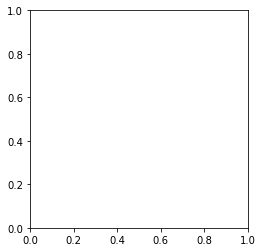

In [293]:
plt.pie(
    LMPD_311_Analytics,
    labels=None,
    startangle=110,
    colors=["Red","Black"],
    autopct="%1.1f%%")

plt.title("Crimes by Percentage")

plt.legend(
    labels = LMPD_Analytics.index,
    loc="best",
    title="Offense"
)

plt.show()

In [ ]:
yearly_avg = spotify_df.groupby("zip")["Total Streams (Millions)"].mean()
yearly_avg

NameError: name 'spotify_df' is not defined

In [ ]:
category = "agency_responsible"
values = "LMPD"

platform_totals = LMPD_311_Analytics.groupby(category)[values].sum()
platform_totals

KeyError: 'Column not found: LMPD'